# Statistics for ML, Deep Learning & Modern AI

Statistics is how we **understand data** before modeling it, **diagnose models** after training them,  
and **evaluate results** rigorously enough to trust them.

| Section | Topic | Used In |
|---|---|---|
| 1 | Descriptive Statistics | EDA, feature engineering |
| 2 | Distributions & the CLT | Why Gaussian assumptions work |
| 3 | Correlation & Covariance | Feature selection, PCA |
| 4 | Hypothesis Testing & p-values | A/B testing, model comparison |
| 5 | Confidence Intervals | Error bars, uncertainty estimation |
| 6 | Statistical Tests for ML | Comparing model performance |
| 7 | Information Theory | Decision trees, cross-entropy loss |
| 8 | Statistics in Deep Learning | Batch norm, weight init, learning rate |
| 9 | Statistics in Transformers | Attention temperature, token distributions |
| 10 | Statistics in Generative AI | FID score, perplexity, sampling |

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 1. Descriptive Statistics

The first thing you do with any dataset: **summarize it**.  
These numbers tell you the shape, center, and spread of your data.

| Statistic | What it measures | Formula |
|---|---|---|
| **Mean** | Center (average) | `Σxᵢ / n` |
| **Median** | Middle value | 50th percentile |
| **Variance** | Average squared distance from mean | `Σ(xᵢ-μ)² / n` |
| **Std Dev (σ)** | Spread in same units as data | `√variance` |
| **Skewness** | Asymmetry | Tail direction |
| **Kurtosis** | Heaviness of tails | Outlier tendency |

> **In ML:** Always run descriptive stats before modeling.  
> Outliers, skewness, and scale differences cause models to fail silently.

=== Descriptive Statistics: House Prices ===
Mean:     $361,106  ← pulled UP by outliers
Median:   $307,517  ← robust to outliers
Std Dev:  $188,927
Q25:      $271,292
Q75:      $347,714
IQR:      $76,422  (Q75 - Q25, outlier-robust spread)
Skewness: 2.494  (right-skewed (luxury tail))
Kurtosis: 5.091  (heavy tails = more outliers than Gaussian)


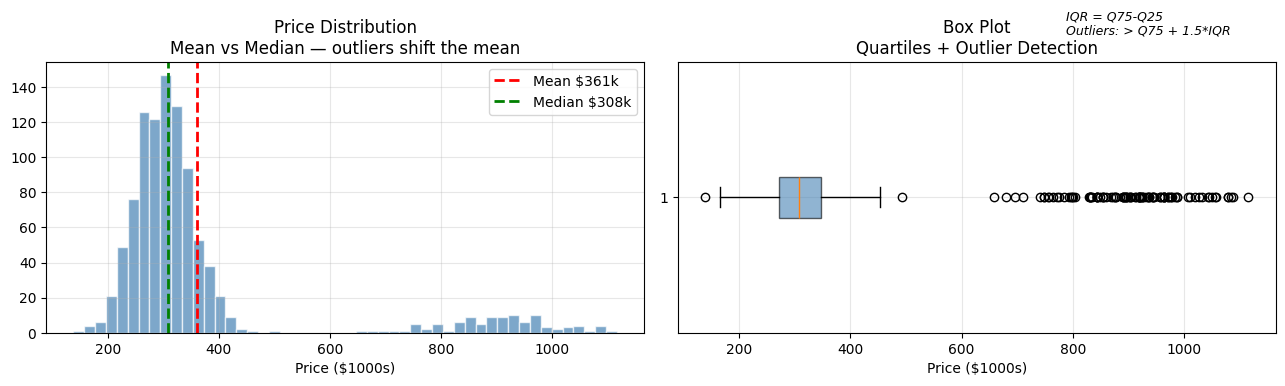


ML implication: Log-transform or clip outliers before feeding to models.
Many algorithms assume roughly Gaussian data — skewed data hurts them.


In [23]:
# Simulate a realistic dataset: house prices
prices = np.concatenate([
    np.random.normal(300_000, 50_000, 900),   # typical houses
    np.random.normal(900_000, 100_000, 100),  # luxury houses (outliers)
])
np.random.shuffle(prices)

mean   = np.mean(prices)
median = np.median(prices)
std    = np.std(prices)
q25, q75 = np.percentile(prices, [25, 75])
iqr    = q75 - q25

print("=== Descriptive Statistics: House Prices ===")
print(f"Mean:     ${mean:,.0f}  ← pulled UP by outliers")
print(f"Median:   ${median:,.0f}  ← robust to outliers")
print(f"Std Dev:  ${std:,.0f}")
print(f"Q25:      ${q25:,.0f}")
print(f"Q75:      ${q75:,.0f}")
print(f"IQR:      ${iqr:,.0f}  (Q75 - Q25, outlier-robust spread)")

skewness = stats.skew(prices)
kurtosis = stats.kurtosis(prices)
print(f"Skewness: {skewness:.3f}  ({'right-skewed (luxury tail)' if skewness > 0 else 'left-skewed'})")
print(f"Kurtosis: {kurtosis:.3f}  (heavy tails = more outliers than Gaussian)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(prices/1000, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(mean/1000, color='red', lw=2, linestyle='--', label=f'Mean ${mean/1000:.0f}k')
axes[0].axvline(median/1000, color='green', lw=2, linestyle='--', label=f'Median ${median/1000:.0f}k')
axes[0].set_title('Price Distribution\nMean vs Median — outliers shift the mean')
axes[0].set_xlabel('Price ($1000s)')
axes[0].legend()

# Box plot
axes[1].boxplot(prices/1000, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot\nQuartiles + Outlier Detection')
axes[1].set_xlabel('Price ($1000s)')
axes[1].text(0.65, 1.1, 'IQR = Q75-Q25\nOutliers: > Q75 + 1.5*IQR', transform=axes[1].transAxes, fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print("\nML implication: Log-transform or clip outliers before feeding to models.")
print("Many algorithms assume roughly Gaussian data — skewed data hurts them.")

---
## 2. Distributions & the Central Limit Theorem (CLT)

### Central Limit Theorem (CLT)
> *The mean of many independent random samples will be approximately normally distributed,  
> regardless of the shape of the original distribution.*

**Why this matters enormously in ML:**
- Justifies using Gaussian noise assumptions in regression
- Explains why mini-batch gradient estimates are reliable
- Why averaging many weak models (bagging) works
- Why training loss curves smooth out over epochs

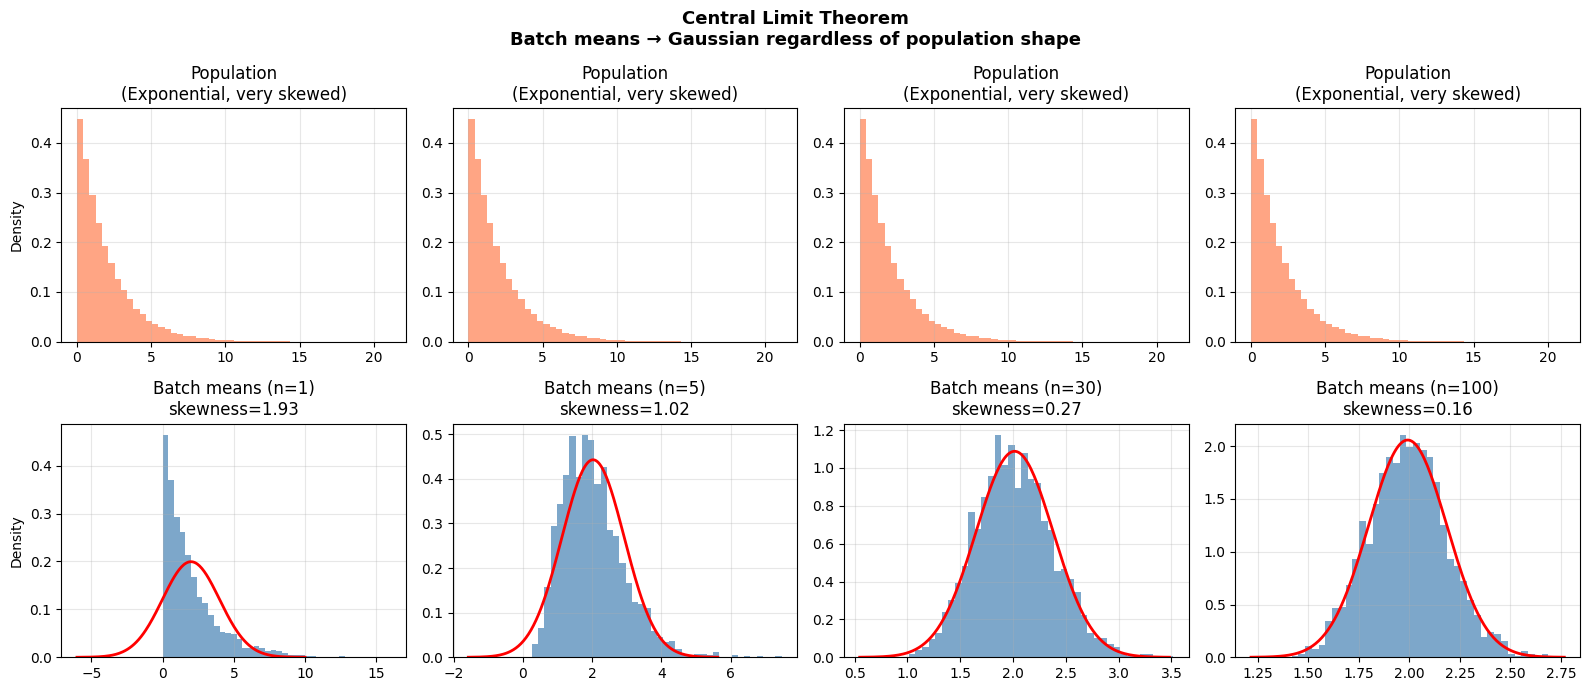

Key insight for deep learning:
Mini-batch gradient estimates (n=32 or 64) are approximately Gaussian.
This is why SGD with small batches still converges reliably.


In [24]:
# Demonstrate CLT with a heavily skewed distribution
# Original: exponential (very skewed)
population = np.random.exponential(scale=2.0, size=100_000)

sample_sizes = [1, 5, 30, 100]
n_samples = 2000

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col, n in enumerate(sample_sizes):
    # Draw n_samples batches of size n, compute each batch mean
    batch_means = [np.mean(np.random.choice(population, n)) for _ in range(n_samples)]

    axes[0, col].hist(population, bins=50, density=True, color='coral', alpha=0.7)
    axes[0, col].set_title('Population\n(Exponential, very skewed)')
    if col == 0:
        axes[0, col].set_ylabel('Density')

    axes[1, col].hist(batch_means, bins=40, density=True, color='steelblue', alpha=0.7)
    # Overlay Gaussian fit
    m, s = np.mean(batch_means), np.std(batch_means)
    x_range = np.linspace(m-4*s, m+4*s, 200)
    axes[1, col].plot(x_range, norm.pdf(x_range, m, s), 'r-', lw=2)
    axes[1, col].set_title(f'Batch means (n={n})\nskewness={stats.skew(batch_means):.2f}')
    if col == 0:
        axes[1, col].set_ylabel('Density')

plt.suptitle('Central Limit Theorem\nBatch means → Gaussian regardless of population shape',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight for deep learning:")
print("Mini-batch gradient estimates (n=32 or 64) are approximately Gaussian.")
print("This is why SGD with small batches still converges reliably.")

---
## 3. Correlation & Covariance

**Covariance** measures how two variables move together (in their original units).  
**Correlation** is covariance normalized to [-1, 1] — easier to interpret.

$$\text{Corr}(X,Y) = \frac{\text{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y}$$

| Correlation | Meaning |
|---|---|
| `+1.0` | Perfect positive relationship |
| `0.0` | No linear relationship |
| `-1.0` | Perfect negative relationship |

**In ML:** Highly correlated features add redundancy.  
In regression, correlated features cause **multicollinearity** (unstable weights).  
PCA removes correlated features by finding independent directions.

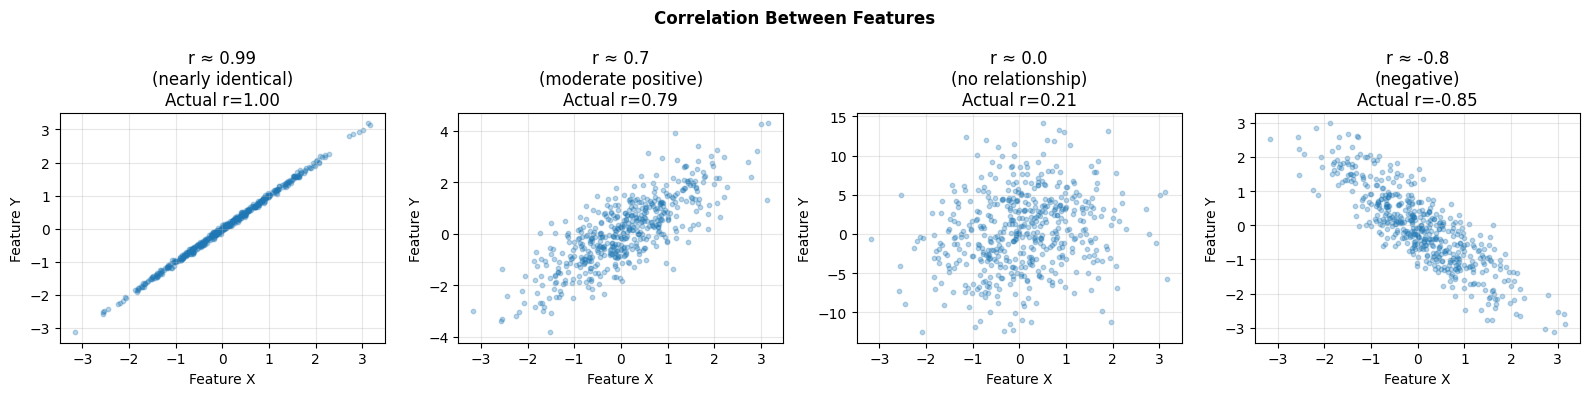

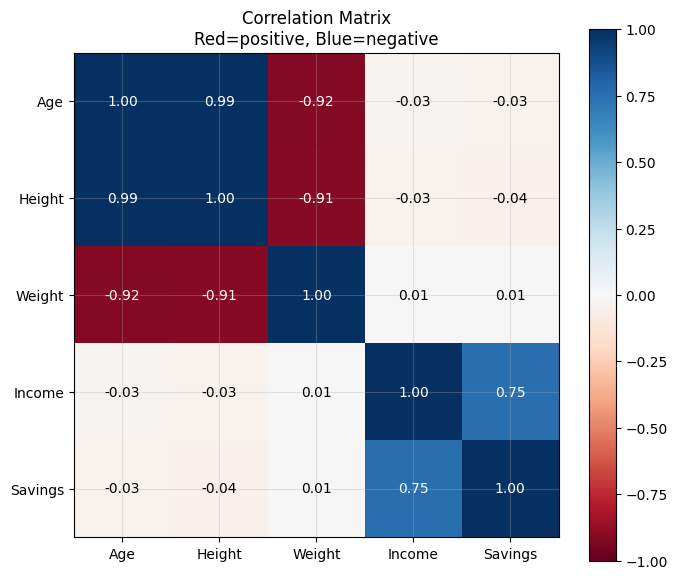

ML takeaway: f1 and f2 are nearly identical (r=0.9).
In a regression model, keeping both causes multicollinearity.
PCA would merge them into one component.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create features with different correlation levels
n = 500
x = np.random.randn(n)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, noise_scale) in zip(axes, [
    ('r ≈ 0.99\n(nearly identical)', 0.05),
    ('r ≈ 0.7\n(moderate positive)', 0.8),
    ('r ≈ 0.0\n(no relationship)', 5.0),
    ('r ≈ -0.8\n(negative)', None),
]):
    if noise_scale is not None:
        y = x + np.random.randn(n) * noise_scale
    else:
        y = -x + np.random.randn(n) * 0.6
    r = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, alpha=0.3, s=10)
    ax.set_title(f'{label}\nActual r={r:.2f}')
    ax.set_xlabel('Feature X')
    ax.set_ylabel('Feature Y')

plt.suptitle('Correlation Between Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation matrix for a dataset with 5 features
np.random.seed(0)
f1 = np.random.randn(200)
f2 = 0.9 * f1 + 0.1 * np.random.randn(200)   # very correlated with f1
f3 = -0.7 * f1 + 0.3 * np.random.randn(200)  # negatively correlated
f4 = np.random.randn(200)                     # independent
f5 = 0.5 * f4 + 0.5 * np.random.randn(200)   # moderately correlated with f4

data = np.column_stack([f1, f2, f3, f4, f5])
df = pd.DataFrame(data, columns=["f1", "f2", "f3", "f4", "f5"])
corr = df.select_dtypes(include="number").corr()
names = ['Age', 'Height', 'Weight', 'Income', 'Savings']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(names)
ax.set_yticklabels(names)

corr_matrix = corr.to_numpy()

for i in range(5):
  for j in range(5):
      value = corr_matrix[i, j]
      ax.text(
          j,
          i,
          f"{value:.2f}",
          ha="center",
          va="center",
          fontsize=10,
          color="white" if abs(value) > 0.5 else "black"
      )
ax.set_title('Correlation Matrix\nRed=positive, Blue=negative')
plt.tight_layout()
plt.show()

print("ML takeaway: f1 and f2 are nearly identical (r=0.9).")
print("In a regression model, keeping both causes multicollinearity.")
print("PCA would merge them into one component.")

---
## 4. Hypothesis Testing & p-values

**Hypothesis testing** is how we decide if an observed result is real or just random chance.

```
H₀ (Null hypothesis):      The effect is zero — any difference is random noise
H₁ (Alternative):          The effect is real

p-value: probability of seeing this result (or more extreme) IF H₀ were true
```

| p-value | Interpretation |
|---|---|
| `p < 0.05` | Statistically significant (reject H₀) |
| `p > 0.05` | Not significant (fail to reject H₀) |
| `p < 0.001` | Highly significant |

**In ML:** Used in A/B testing (did model B actually improve over model A?),  
feature selection (is this feature actually predictive?), and experiment reporting.

=== A/B Test: New Model vs Baseline ===
Baseline mean accuracy: 0.8144 ± 0.0265
New model mean accuracy: 0.8464 ± 0.0275
Mean improvement:       0.0320 (3.20%)
t-statistic:            4.7538
p-value:                0.000050

✓ p=0.0001 < 0.05 → Improvement is statistically significant
  We can be confident the new model is genuinely better


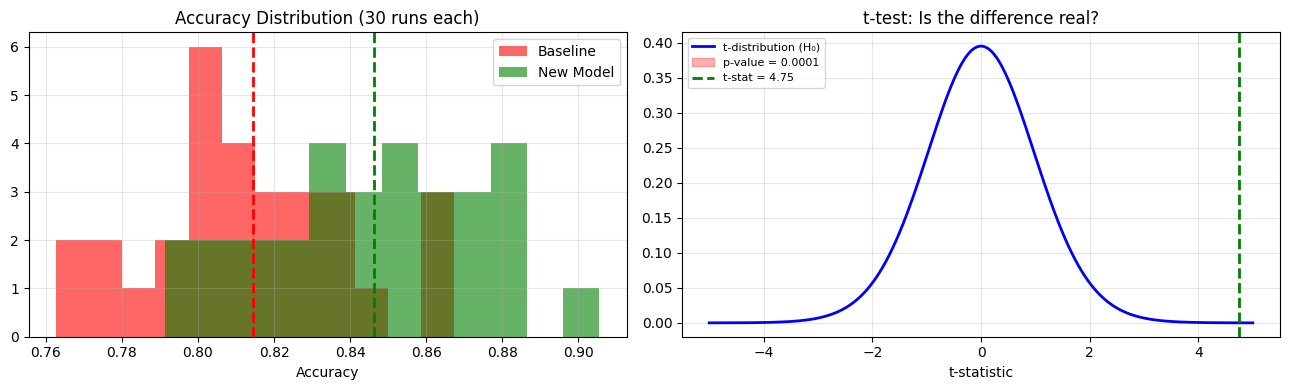


=== Common Mistakes ===
Type I error  (False Positive): p<0.05 but effect is random (α error)
Type II error (False Negative): p>0.05 but effect IS real (β error)
With p<0.05 threshold: 5% chance of Type I error even with no real effect
Running 20 experiments, ~1 will show p<0.05 by pure chance!


In [26]:
from scipy import stats

# Example: Did our new model actually improve over the baseline?
# We run both models on 30 different random seeds and compare accuracy

np.random.seed(42)
baseline_accs = np.random.normal(0.82, 0.03, 30)  # baseline model
new_model_accs = np.random.normal(0.85, 0.03, 30)  # new model

# Paired t-test (same datasets, different models)
t_stat, p_value = stats.ttest_rel(new_model_accs, baseline_accs)
mean_diff = np.mean(new_model_accs - baseline_accs)

print("=== A/B Test: New Model vs Baseline ===")
print(f"Baseline mean accuracy: {baseline_accs.mean():.4f} ± {baseline_accs.std():.4f}")
print(f"New model mean accuracy: {new_model_accs.mean():.4f} ± {new_model_accs.std():.4f}")
print(f"Mean improvement:       {mean_diff:.4f} ({mean_diff*100:.2f}%)")
print(f"t-statistic:            {t_stat:.4f}")
print(f"p-value:                {p_value:.6f}")
print()
if p_value < 0.05:
    print(f"✓ p={p_value:.4f} < 0.05 → Improvement is statistically significant")
    print("  We can be confident the new model is genuinely better")
else:
    print(f"✗ p={p_value:.4f} > 0.05 → Improvement could be random chance")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of accuracies
axes[0].hist(baseline_accs, bins=12, alpha=0.6, color='red', label='Baseline')
axes[0].hist(new_model_accs, bins=12, alpha=0.6, color='green', label='New Model')
axes[0].axvline(baseline_accs.mean(), color='red', lw=2, linestyle='--')
axes[0].axvline(new_model_accs.mean(), color='green', lw=2, linestyle='--')
axes[0].set_title('Accuracy Distribution (30 runs each)')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

# p-value under null distribution
x_t = np.linspace(-5, 5, 300)
axes[1].plot(x_t, stats.t.pdf(x_t, df=29), 'b-', lw=2, label='t-distribution (H₀)')
axes[1].fill_between(x_t, stats.t.pdf(x_t, df=29),
                    where=np.abs(x_t) >= abs(t_stat), alpha=0.3, color='red',
                    label=f'p-value = {p_value:.4f}')
axes[1].axvline(t_stat, color='green', lw=2, linestyle='--', label=f't-stat = {t_stat:.2f}')
axes[1].set_title('t-test: Is the difference real?')
axes[1].set_xlabel('t-statistic')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Type I and Type II errors
print("\n=== Common Mistakes ===")
print("Type I error  (False Positive): p<0.05 but effect is random (α error)")
print("Type II error (False Negative): p>0.05 but effect IS real (β error)")
print("With p<0.05 threshold: 5% chance of Type I error even with no real effect")
print("Running 20 experiments, ~1 will show p<0.05 by pure chance!")

---
## 5. Confidence Intervals

A **confidence interval** gives a range of plausible values for a statistic.

> "I am 95% confident the true accuracy is between 81.2% and 84.8%"

$$\text{CI} = \bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

**In ML:** Always report confidence intervals alongside metrics.  
A model with 85% ± 0.1% is very different from 85% ± 5%.

Model Accuracy: 0.8498
95% CI: [0.8433, 0.8563]
Width:  0.0129  ← smaller is better (need more samples)


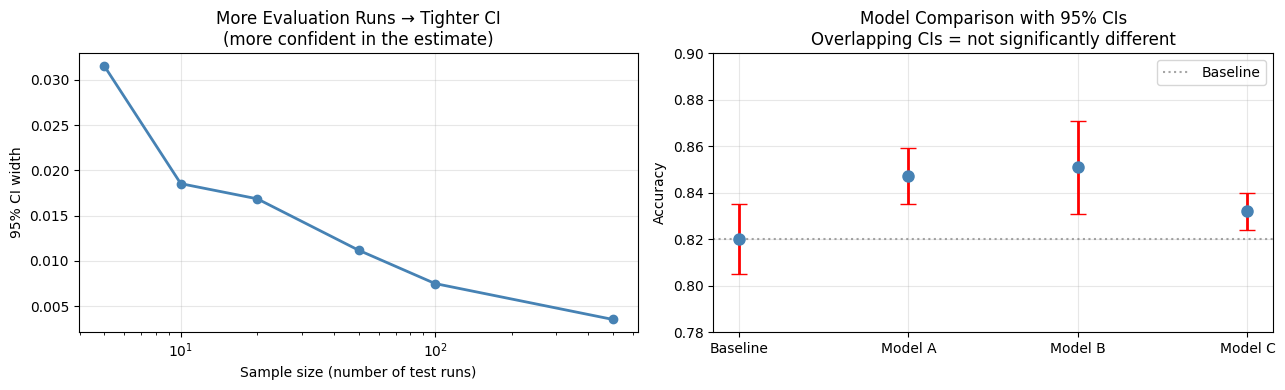

Model B looks best by mean, but its CI overlaps A. Not significantly better.
Model A with tighter CI is a more reliable result.


In [27]:
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)   # standard error = std / sqrt(n)
    ci = stats.t.interval(confidence, df=n-1, loc=mean, scale=se)
    return mean, ci[0], ci[1]

# Model evaluation with confidence intervals
np.random.seed(0)
model_accs = np.random.normal(0.847, 0.02, 50)

mean, lo, hi = confidence_interval(model_accs)
print(f"Model Accuracy: {mean:.4f}")
print(f"95% CI: [{lo:.4f}, {hi:.4f}]")
print(f"Width:  {hi-lo:.4f}  ← smaller is better (need more samples)")

# How CI width changes with sample size
sample_sizes = [5, 10, 20, 50, 100, 500]
ci_widths = []
for n in sample_sizes:
    sample = np.random.normal(0.847, 0.02, n)
    _, lo, hi = confidence_interval(sample)
    ci_widths.append(hi - lo)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(sample_sizes, ci_widths, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Sample size (number of test runs)')
axes[0].set_ylabel('95% CI width')
axes[0].set_title('More Evaluation Runs → Tighter CI\n(more confident in the estimate)')
axes[0].set_xscale('log')

# Comparing two models with CIs
models = ['Baseline', 'Model A', 'Model B', 'Model C']
means  = [0.820, 0.847, 0.851, 0.832]
errors = [0.015, 0.012, 0.020, 0.008]  # half-width of CI

axes[1].errorbar(range(len(models)), means, yerr=errors, fmt='o', capsize=6,
                 color='steelblue', ecolor='red', markersize=8, lw=2)
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Comparison with 95% CIs\nOverlapping CIs = not significantly different')
axes[1].set_ylim(0.78, 0.90)

# Add reference line
axes[1].axhline(means[0], color='gray', linestyle=':', alpha=0.7, label='Baseline')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Model B looks best by mean, but its CI overlaps A. Not significantly better.")
print("Model A with tighter CI is a more reliable result.")

---
## 6. Statistical Tests for ML

Specific tests used when evaluating and comparing ML models.

| Test | When to use |
|---|---|
| **Paired t-test** | Compare two models on same datasets |
| **McNemar's test** | Compare classifiers on same test set |
| **Wilcoxon signed-rank** | Non-parametric, when data isn't Gaussian |
| **Bootstrap** | General-purpose CI without distribution assumptions |

**Bootstrap** is the most practical for ML — it makes no distributional assumptions.

=== Bootstrap Confidence Intervals ===
Model A: 0.8489  95% CI: [0.8260, 0.8710]
Model B: 0.8339  95% CI: [0.8100, 0.8560]

Bootstrap p-value (B > A): 0.8320
✗ Difference not significant


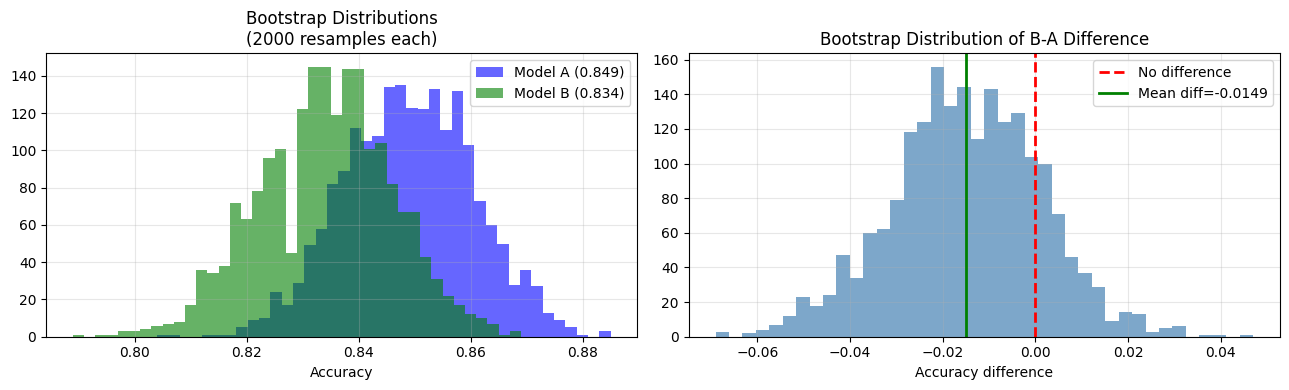

In [28]:
# Bootstrap confidence interval — the most useful technique in practice
def bootstrap_ci(data, stat_fn=np.mean, n_boot=2000, confidence=0.95):
    boot_stats = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_stats.append(stat_fn(sample))
    boot_stats = np.array(boot_stats)
    alpha = (1 - confidence) / 2
    lo, hi = np.percentile(boot_stats, [alpha*100, (1-alpha)*100])
    return np.mean(boot_stats), lo, hi, boot_stats

# Test set accuracy scores (per sample: 1=correct, 0=incorrect)
np.random.seed(1)
model_a_correct = (np.random.rand(1000) < 0.847).astype(float)
model_b_correct = (np.random.rand(1000) < 0.863).astype(float)

mean_a, lo_a, hi_a, boot_a = bootstrap_ci(model_a_correct)
mean_b, lo_b, hi_b, boot_b = bootstrap_ci(model_b_correct)

print("=== Bootstrap Confidence Intervals ===")
print(f"Model A: {mean_a:.4f}  95% CI: [{lo_a:.4f}, {hi_a:.4f}]")
print(f"Model B: {mean_b:.4f}  95% CI: [{lo_b:.4f}, {hi_b:.4f}]")

# Bootstrap test of difference
boot_diff = boot_b - np.array([np.mean(np.random.choice(model_a_correct, 1000, replace=True))
                                for _ in range(2000)])
p_boot = np.mean(boot_diff <= 0)
print(f"\nBootstrap p-value (B > A): {p_boot:.4f}")
print(f"{'✓ B is significantly better' if p_boot < 0.05 else '✗ Difference not significant'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(boot_a, bins=40, alpha=0.6, color='blue', label=f'Model A ({mean_a:.3f})')
axes[0].hist(boot_b, bins=40, alpha=0.6, color='green', label=f'Model B ({mean_b:.3f})')
axes[0].set_title('Bootstrap Distributions\n(2000 resamples each)')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

axes[1].hist(boot_diff, bins=40, color='steelblue', alpha=0.7)
axes[1].axvline(0, color='red', lw=2, linestyle='--', label='No difference')
axes[1].axvline(np.mean(boot_diff), color='green', lw=2, label=f'Mean diff={np.mean(boot_diff):.4f}')
axes[1].set_title('Bootstrap Distribution of B-A Difference')
axes[1].set_xlabel('Accuracy difference')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7. Information Theory

Information theory measures **how much information** a random variable carries.  
It is the mathematical foundation of decision trees, compression, and language models.

### Entropy — amount of uncertainty
$$H(X) = -\sum_i p_i \log_2 p_i \quad \text{(bits)}$$

### Information Gain — used in decision trees
$$IG = H(\text{parent}) - \sum_k \frac{|S_k|}{|S|} H(S_k)$$

Split on the feature that gives the **most information gain** = reduces uncertainty most.

=== Information Gain for Decision Tree Split ===
Parent entropy (50/50):  1.0000 bits

Feature A (FREE):     IG = 0.1245
Feature B (meeting):  IG = 0.3958
→ Split on B (meeting) — reduces uncertainty more


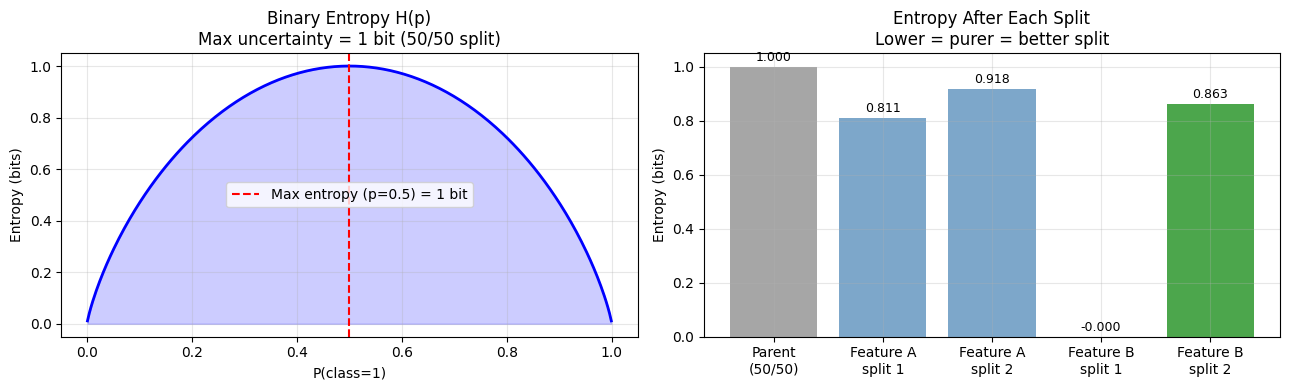

In [29]:
def entropy(probs):
    probs = np.array(probs)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def information_gain(parent, splits):
    total = sum(len(s) for s in splits)
    weighted_entropy = sum(len(s)/total * entropy(np.bincount(s)/len(s)) for s in splits)
    return entropy(np.bincount(parent)/len(parent)) - weighted_entropy

# Decision tree feature selection example
labels = np.array([1,1,1,1,1,0,0,0,0,0])   # 5 spam, 5 not spam → entropy = 1.0

# Feature A: "contains FREE" — splits into [3 spam, 1 not] and [2 spam, 4 not]
# Feature B: "contains meeting" — splits into [0 spam, 3 not] and [5 spam, 2 not]
split_A = [np.array([1,1,1,0]), np.array([1,1,0,0,0,0])]
split_B = [np.array([0,0,0]),   np.array([1,1,1,1,1,0,0])]

ig_A = information_gain(labels, split_A)
ig_B = information_gain(labels, split_B)

print("=== Information Gain for Decision Tree Split ===")
print(f"Parent entropy (50/50):  {entropy([0.5, 0.5]):.4f} bits")
print()
print(f"Feature A (FREE):     IG = {ig_A:.4f}")
print(f"Feature B (meeting):  IG = {ig_B:.4f}")
print(f"→ Split on {'A (FREE)' if ig_A > ig_B else 'B (meeting)'} — reduces uncertainty more")

# Visualize entropy as uncertainty
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

p_vals = np.linspace(0.001, 0.999, 300)
h_vals = [-p*np.log2(p) - (1-p)*np.log2(1-p) for p in p_vals]
axes[0].plot(p_vals, h_vals, 'b-', lw=2)
axes[0].axvline(0.5, color='red', linestyle='--', label='Max entropy (p=0.5) = 1 bit')
axes[0].fill_between(p_vals, h_vals, alpha=0.2, color='blue')
axes[0].set_title('Binary Entropy H(p)\nMax uncertainty = 1 bit (50/50 split)')
axes[0].set_xlabel('P(class=1)')
axes[0].set_ylabel('Entropy (bits)')
axes[0].legend()

# Information gain visualization
categories = ['Parent\n(50/50)', 'Feature A\nsplit 1', 'Feature A\nsplit 2',
              'Feature B\nsplit 1', 'Feature B\nsplit 2']
entropies = [
    entropy([0.5, 0.5]),
    entropy([3/4, 1/4]),
    entropy([2/6, 4/6]),
    entropy([0/3, 3/3]),
    entropy([5/7, 2/7]),
]
colors = ['gray', 'steelblue', 'steelblue', 'green', 'green']
axes[1].bar(categories, entropies, color=colors, alpha=0.7)
axes[1].set_title('Entropy After Each Split\nLower = purer = better split')
axes[1].set_ylabel('Entropy (bits)')
for i, h in enumerate(entropies):
    axes[1].text(i, h+0.02, f'{h:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Statistics in Deep Learning

Statistics drives the design decisions inside neural networks.

### Batch Normalization
Normalizes layer inputs to zero mean, unit variance — keeping statistics stable during training.  
Without it, the distribution of activations shifts as weights change (**internal covariate shift**).

### Weight Initialization
Poorly initialized weights → exploding or vanishing gradients before training even starts.  
**Xavier init:** `W ~ N(0, 1/n_in)` keeps variance stable through layers.  
**He init:** `W ~ N(0, 2/n_in)` designed for ReLU activations.

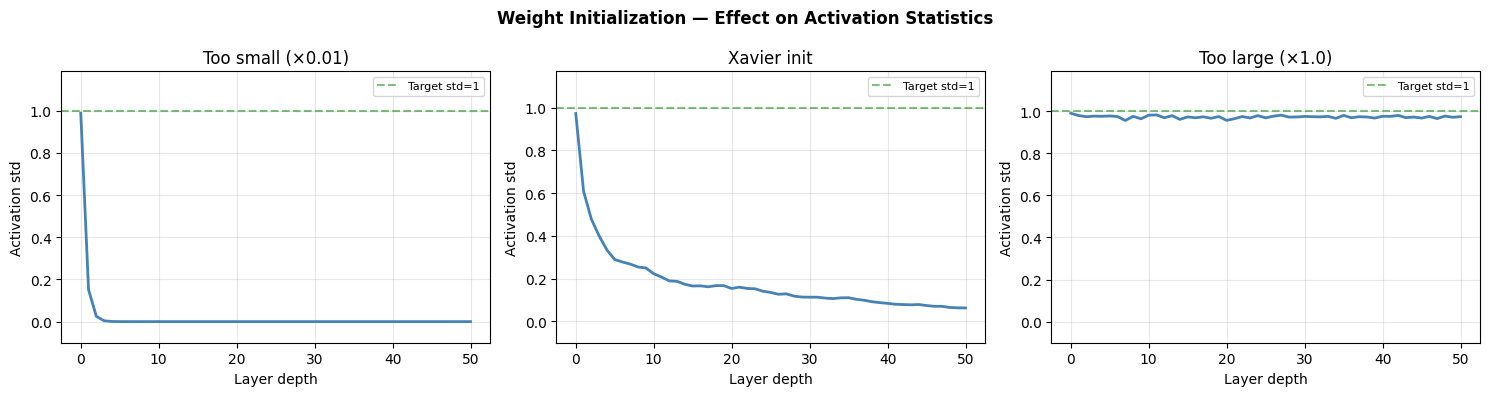

=== Batch Normalization ===
Raw activations:    mean=3.578, std=1.962
After BatchNorm:    mean=0.000, std=1.000
Now: zero mean, unit variance — gradient flow is healthy


In [30]:
# Demonstrate vanishing/exploding gradients with different init strategies
np.random.seed(0)
n_layers = 50
n_units  = 256

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (init_name, scale_fn) in zip(axes, [
    ('Too small (×0.01)',  lambda n: 0.01),
    ('Xavier init',        lambda n: np.sqrt(1.0/n)),
    ('Too large (×1.0)',   lambda n: 1.0),
]):
    x = np.random.randn(n_units)
    layer_stds = [x.std()]

    for _ in range(n_layers):
        W = np.random.randn(n_units, n_units) * scale_fn(n_units)
        x = np.tanh(W @ x)
        layer_stds.append(x.std())

    ax.plot(layer_stds, lw=2, color='steelblue')
    ax.axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Target std=1')
    ax.set_title(f'{init_name}')
    ax.set_xlabel('Layer depth')
    ax.set_ylabel('Activation std')
    ax.set_ylim(-0.1, max(layer_stds)*1.1 + 0.1)
    ax.legend(fontsize=8)

plt.suptitle('Weight Initialization — Effect on Activation Statistics',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Batch normalization effect
np.random.seed(1)
raw_activations = np.random.normal(3.5, 2.0, 1000)  # shifted, scaled

def batch_norm(x, gamma=1.0, beta=0.0, eps=1e-8):
    mu = np.mean(x)
    var = np.var(x)
    x_norm = (x - mu) / np.sqrt(var + eps)
    return gamma * x_norm + beta

normed = batch_norm(raw_activations)
print("=== Batch Normalization ===")
print(f"Raw activations:    mean={raw_activations.mean():.3f}, std={raw_activations.std():.3f}")
print(f"After BatchNorm:    mean={normed.mean():.3f}, std={normed.std():.3f}")
print("Now: zero mean, unit variance — gradient flow is healthy")

---
## 9. Statistics in Transformers

### Layer Normalization (vs Batch Normalization)
Transformers use **LayerNorm** (normalize across features within one sample, not across the batch).  
Batch size varies, sequence length varies — LayerNorm is more stable for sequential data.

### Attention Statistics
The `softmax(QKᵀ/√dk)` produces a probability distribution.  
Entropy of attention weights reveals **attention patterns**:
- **Low entropy** → sharp, focused attention on a few tokens
- **High entropy** → diffuse, attending to many tokens equally

=== Attention Pattern Statistics ===
T= 0.1:  entropy=0.000 bits  max_prob=1.000  (focused)
T= 0.5:  entropy=0.889 bits  max_prob=0.851  (focused)
T= 1.0:  entropy=2.359 bits  max_prob=0.507  (moderate)
T= 2.0:  entropy=3.081 bits  max_prob=0.267  (diffuse)
T= 5.0:  entropy=3.287 bits  max_prob=0.154  (diffuse)


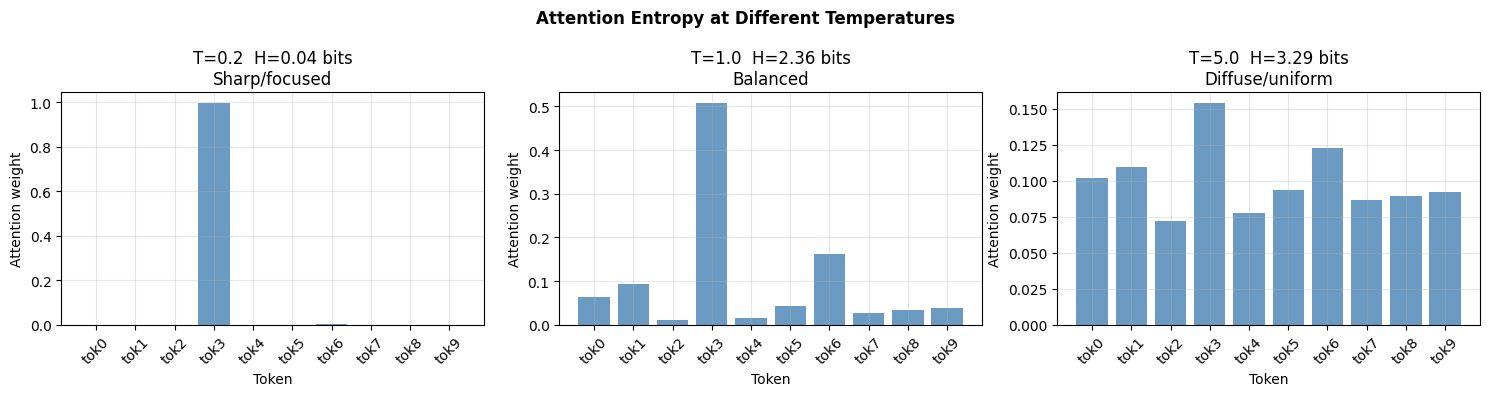


=== LayerNorm vs BatchNorm ===
                     Mean per sample  Std per sample
  LayerNorm sample 0: mean=-0.0000  std=1.0000
  LayerNorm sample 1: mean=+0.0000  std=1.0000
  LayerNorm sample 2: mean=-0.0000  std=1.0000
  LayerNorm sample 3: mean=+0.0000  std=1.0000
LayerNorm: each sample has mean=0, std=1 (normalized within each sample)
BatchNorm: each feature has mean=0, std=1 (normalized across the batch)


In [31]:
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def entropy_bits(p):
    p = p[p > 1e-10]
    return -np.sum(p * np.log2(p))

# Attention entropy at different temperatures
np.random.seed(2)
logits = np.random.randn(10)  # attention scores for 10 tokens
vocab = [f'tok{i}' for i in range(10)]

print("=== Attention Pattern Statistics ===")
for T in [0.1, 0.5, 1.0, 2.0, 5.0]:
    probs = softmax(logits / T)
    H = entropy_bits(probs)
    max_p = probs.max()
    print(f"T={T:4.1f}:  entropy={H:.3f} bits  max_prob={max_p:.3f}  "
          f"({'focused' if H < 1.5 else 'diffuse' if H > 2.5 else 'moderate'})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, T in zip(axes, [0.2, 1.0, 5.0]):
    probs = softmax(logits / T)
    H = entropy_bits(probs)
    ax.bar(vocab, probs, color='steelblue', alpha=0.8)
    ax.set_title(f'T={T}  H={H:.2f} bits\n{"Sharp/focused" if H<1.5 else "Diffuse/uniform" if H>2.5 else "Balanced"}')
    ax.set_xlabel('Token')
    ax.set_ylabel('Attention weight')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Attention Entropy at Different Temperatures', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# LayerNorm vs BatchNorm
np.random.seed(0)
batch = np.random.normal(2, 3, (4, 6))  # 4 samples, 6 features

def layer_norm(x, eps=1e-8):
    mu  = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mu) / (std + eps)

def batch_norm_2d(x, eps=1e-8):
    mu  = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True)
    return (x - mu) / (std + eps)

ln = layer_norm(batch)
bn = batch_norm_2d(batch)
print("\n=== LayerNorm vs BatchNorm ===")
print(f"{'':20} Mean per sample  Std per sample")
for i in range(4):
    print(f"  LayerNorm sample {i}: mean={ln[i].mean():+.4f}  std={ln[i].std():.4f}")
print("LayerNorm: each sample has mean=0, std=1 (normalized within each sample)")
print("BatchNorm: each feature has mean=0, std=1 (normalized across the batch)")

---
## 10. Statistics in Generative AI

### Perplexity — how well does a language model predict text?
$$\text{Perplexity} = 2^{H(p,q)} = 2^{-\frac{1}{N}\sum_i \log_2 q(x_i)}$$
- Lower perplexity = model assigns higher probability to real text
- GPT-2: ~30 perplexity on WikiText. GPT-4: much lower.

### FID Score (Fréchet Inception Distance)
Measures the quality of generated images by comparing statistics of real vs generated:
$$\text{FID} = ||\mu_r - \mu_g||^2 + \text{Tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r\Sigma_g)^{1/2})$$
- Lower FID = generated images are more realistic
- Compares mean and covariance of feature distributions

=== Perplexity ===
Good model perplexity:  1.94
Bad model perplexity:   19.76
Random (vocab=10k):     10000
Lower perplexity = model is less 'surprised' by the text


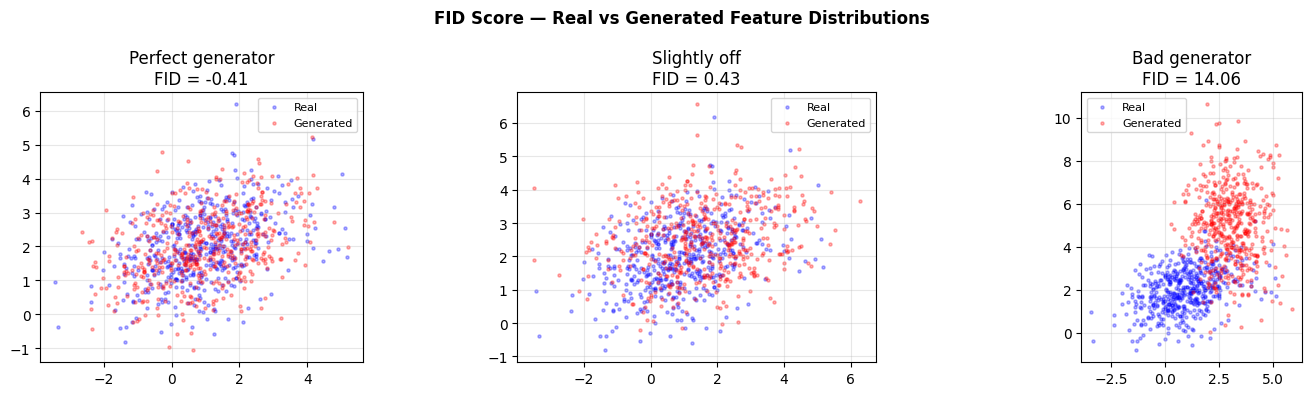

In [32]:
# Perplexity calculation
def perplexity(log_probs):
    # log_probs: log2 probabilities of each token
    # N = len(log_probs)
    avg_neg_log_prob = -np.mean(log_probs)
    return 2 ** avg_neg_log_prob

# Simulate language model predictions
np.random.seed(0)
# Good model: assigns high probability to correct tokens
good_log_probs  = np.log2(np.random.uniform(0.3, 0.8, 100))
# Bad model: assigns low probability to correct tokens
bad_log_probs   = np.log2(np.random.uniform(0.01, 0.1, 100))

print("=== Perplexity ===")
print(f"Good model perplexity:  {perplexity(good_log_probs):.2f}")
print(f"Bad model perplexity:   {perplexity(bad_log_probs):.2f}")
print(f"Random (vocab=10k):     {10_000:.0f}")
print("Lower perplexity = model is less 'surprised' by the text")

# FID score (simplified 1D version)
def simplified_fid(real_features, gen_features):
    mu_r, mu_g = np.mean(real_features, axis=0), np.mean(gen_features, axis=0)
    cov_r = np.cov(real_features.T)
    cov_g = np.cov(gen_features.T)
    mean_diff = np.sum((mu_r - mu_g)**2)
    cov_diff  = np.trace(cov_r + cov_g - 2*np.sqrt(cov_r @ cov_g + 1e-8*np.eye(len(mu_r))))
    return mean_diff + cov_diff

np.random.seed(1)
real_features = np.random.multivariate_normal([1, 2], [[2, 0.5],[0.5, 1]], 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    ('Perfect generator', [1.0, 2.0], [[2, 0.5],[0.5, 1]]),
    ('Slightly off',      [1.5, 2.5], [[2.5, 0.3],[0.3, 1.2]]),
    ('Bad generator',     [3.0, 5.0], [[1, 0],[0, 3]]),
]
for ax, (title, mu, cov) in zip(axes, configs):
    gen = np.random.multivariate_normal(mu, cov, 500)
    fid = simplified_fid(real_features, gen)
    ax.scatter(real_features[:,0], real_features[:,1], s=5, alpha=0.3, color='blue', label='Real')
    ax.scatter(gen[:,0], gen[:,1], s=5, alpha=0.3, color='red', label='Generated')
    ax.set_title(f'{title}\nFID = {fid:.2f}')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('FID Score — Real vs Generated Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary — Statistics Across the Stack

```
Classic ML
  └── Descriptive stats         → Understand data before modeling
  └── Correlation matrix        → Feature selection, spot multicollinearity
  └── Hypothesis testing        → A/B testing, feature significance
  └── Confidence intervals      → Report results honestly
  └── Information gain          → Decision tree splitting criterion

Deep Learning
  └── Weight init stats         → Xavier/He: keep variance=1 through layers
  └── Batch normalization       → Force zero mean, unit variance per batch
  └── CLT                       → Why mini-batch gradients are reliable

Transformers
  └── Layer normalization       → Per-sample normalization for sequences
  └── Attention entropy         → Low=focused, High=diffuse attention

Generative AI
  └── Perplexity                → LLM quality: lower = better text prediction
  └── FID score                 → Image generation quality: lower = more realistic
  └── Bootstrap CI              → Compare models without distribution assumptions
```

### What to learn next
- **model_evaluation.ipynb** → metrics (F1, AUC-ROC), cross-validation, learning curves
- **regression.ipynb** → these stats are used to evaluate regression models (R², RMSE)
- **decision_trees.ipynb** → information gain used directly to build the tree